In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
data = pd.read_csv('/Users/yume/PycharmProjects/IntermediateDataScience/PBL1/data/hdb_resale_prices_final.csv')

<Axes: >

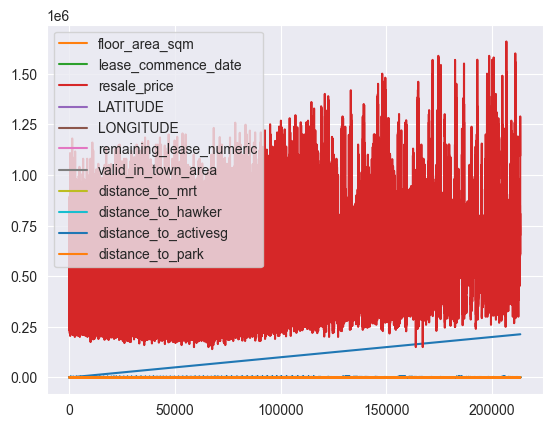

In [4]:
data.plot()

In [22]:
numeric_data = data.apply(pd.to_numeric, errors='coerce')

print("Usable numeric values per column:")
print(numeric_data.count())

print("Columns with at least 2 numeric values:")
print(numeric_data.columns[numeric_data.count() >= 2])

Usable numeric values per column:
dataset_id                      0
dataset_name                    0
_id                        213342
month                           0
town                            0
flat_type                       0
block                      136214
street_name                     0
storey_range                    0
floor_area_sqm             213342
flat_model                      0
lease_commence_date        213342
remaining_lease                 0
resale_price               213342
LATITUDE                   213342
LONGITUDE                  213342
remaining_lease_numeric    213342
valid_in_town_area         205146
nearest_mrt_exit                0
distance_to_mrt            213342
nearest_hawker                  0
distance_to_hawker         213342
nearest_activesg                0
distance_to_activesg       213342
nearest_park                    0
distance_to_park           213342
dtype: int64
Columns with at least 2 numeric values:
Index(['_id', 'block', 'floor

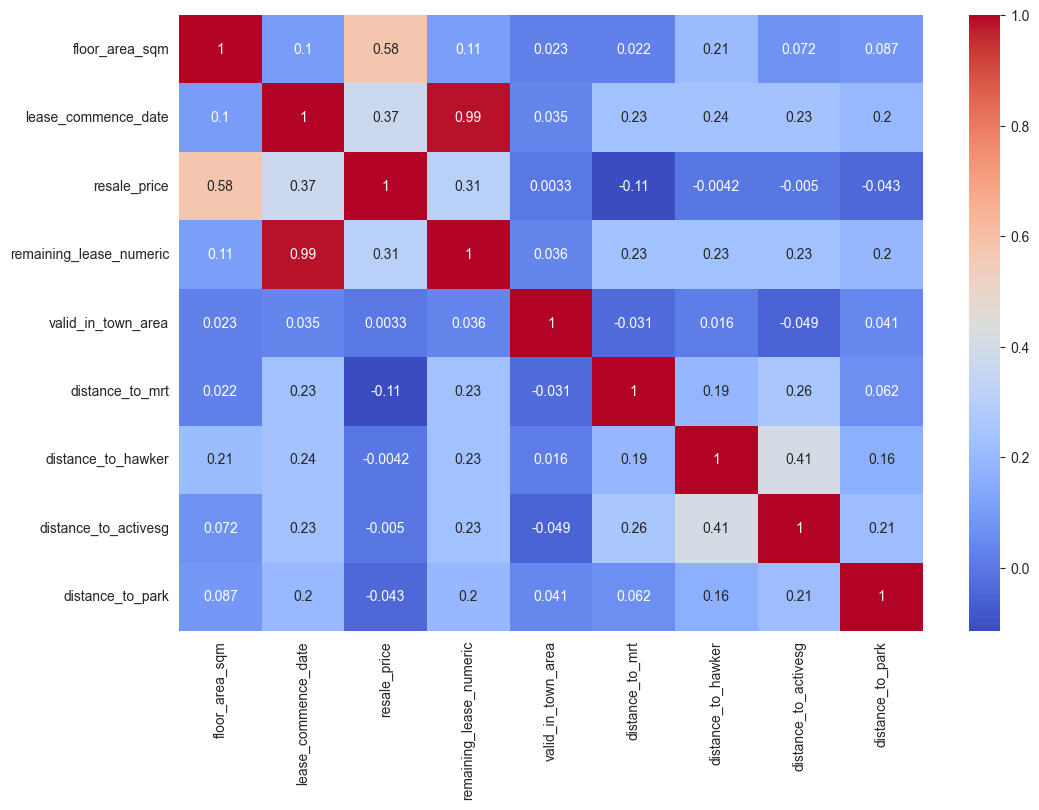

In [5]:
corr_cols = [
    'floor_area_sqm',
    'lease_commence_date',
    'resale_price',
    'remaining_lease_numeric',
    'valid_in_town_area',
    'distance_to_mrt',
    'distance_to_hawker',
    'distance_to_activesg',
    'distance_to_park'
]

corr = data[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [6]:
corr_with_price = data[corr_cols].corr()['resale_price'].sort_values(ascending=False)

print(corr_with_price)

resale_price               1.000000
floor_area_sqm             0.577783
lease_commence_date        0.369566
remaining_lease_numeric    0.307781
valid_in_town_area         0.003274
distance_to_hawker        -0.004232
distance_to_activesg      -0.004980
distance_to_park          -0.043400
distance_to_mrt           -0.113757
Name: resale_price, dtype: float64


In [7]:
data.describe()

,_id,floor_area_sqm,lease_commence_date,resale_price,LATITUDE,LONGITUDE,remaining_lease_numeric,valid_in_town_area,distance_to_mrt,distance_to_hawker,distance_to_activesg,distance_to_park
count,213342.000000,213342.000000,213342.000000,2.133420e+05,213342.000000,213342.000000,213342.000000,205146.000000,213342.000000,213342.000000,213342.00000,213342.000000
mean,106671.500000,96.839137,1996.369763,5.189867e+05,1.368220,103.841236,74.353036,0.999162,733.315795,716.195725,1137.22900,733.708994
std,61586.674902,24.031550,14.254755,1.834341e+05,0.042949,0.071004,14.175294,0.028944,446.535322,470.089942,698.94151,383.682605
min,1.000000,31.000000,1966.000000,1.400000e+05,1.270380,103.685228,40.080000,0.000000,14.630000,0.000000,42.44000,44.220000
25%,53336.250000,82.000000,1985.000000,3.820000e+05,1.337450,103.780459,62.580000,1.000000,407.580000,351.140000,614.17000,449.290000
50%,106671.500000,93.000000,1996.000000,4.880000e+05,1.367779,103.846281,74.170000,1.000000,643.920000,618.860000,989.48000,663.410000
75%,160006.750000,112.000000,2011.000000,6.220000e+05,1.396803,103.898737,88.670000,1.000000,957.210000,970.590000,1518.32000,946.810000
max,213342.000000,366.700000,2022.000000,1.658888e+06,1.457071,103.987805,97.750000,1.000000,3524.740000,2500.130000,4297.08000,2216.900000


<Axes: xlabel='floor_area_sqm'>

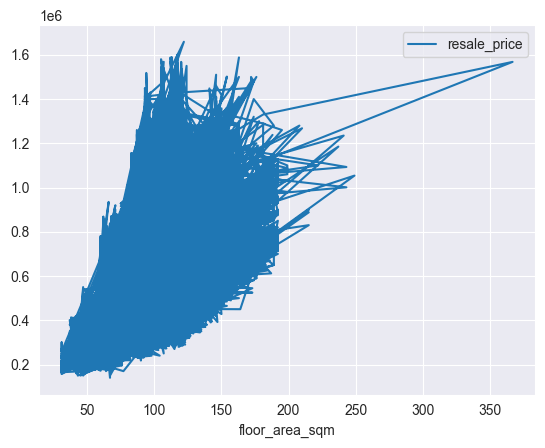

In [12]:
data.plot( 'floor_area_sqm','resale_price' )

<Axes: xlabel='distance_to_mrt', ylabel='resale_price'>

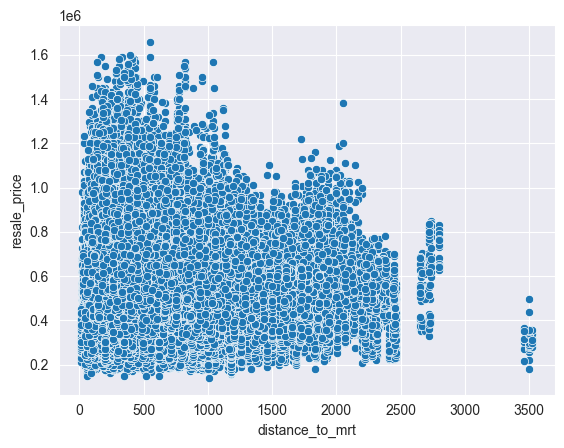

In [14]:
sns.scatterplot( x='distance_to_mrt', y='resale_price', data=data )


<Axes: xlabel='distance_to_park', ylabel='resale_price'>

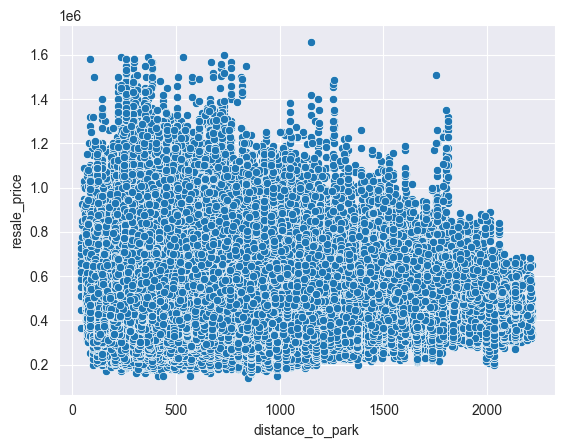

In [17]:
sns.scatterplot( x='distance_to_park', y='resale_price', data=data )


In [18]:
data_bus = pd.read_csv('/Users/yume/PycharmProjects/PBL1/data/hdb_resale_prices_final_with_bus_stops.csv')

In [19]:
data_bus.head()

,dataset_id,dataset_name,_id,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,...,nearest_mrt_exit,distance_to_mrt,nearest_hawker,distance_to_hawker,nearest_activesg,distance_to_activesg,nearest_park,distance_to_park,nearest_bus_stop,distance_to_bus_stop
0,d_8b84c4ee58e3cfc0ece0d773c8ca6abc,hdb_resale_prices,1,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,...,ANG MO KIO MRT STATION,934.25,Ang Mo Kio Ave 10 Blk 409 (Teck Ghee Square),172.41,Ang Mo Kio Swimming Complex,490.34,BISHAN-ANG MO KIO PARK (RIVER PLAINS),581.53,OPP CHRIST THE KING CH,97.97
1,d_8b84c4ee58e3cfc0ece0d773c8ca6abc,hdb_resale_prices,2,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,...,MAYFLOWER MRT STATION,160.18,Ang Mo Kio Ave 4 Blk 160/162 (Mayflower Market),408.45,ActiveSG Gym@Ang Mo Kio Community Centre,533.07,MAYFLOWER CRESCENT PG,244.82,MAYFLOWER STN EXIT 5,168.95
2,d_8b84c4ee58e3cfc0ece0d773c8ca6abc,hdb_resale_prices,3,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,...,LENTOR MRT STATION,390.20,Ang Mo Kio Ave 4 Blk 628 (Ang Mo Kio 628 Market),586.17,Yio Chu Kang Sport Centre,1170.19,SERENADE WALK PG,125.24,BLK 604,138.10
3,d_8b84c4ee58e3cfc0ece0d773c8ca6abc,hdb_resale_prices,4,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,...,ANG MO KIO MRT STATION,885.08,Ang Mo Kio Ave 10 Blk 453A (Chong Boon Market and Food Centre),244.84,Burghley Squash & Tennis Centre,837.12,HAUS LINEAR PARK,366.84,BLK 465,72.02
4,d_8b84c4ee58e3cfc0ece0d773c8ca6abc,hdb_resale_prices,5,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,...,LENTOR MRT STATION,376.98,Ang Mo Kio Ave 4 Blk 628 (Ang Mo Kio 628 Market),611.70,Yio Chu Kang Sport Centre,1191.47,SERENADE WALK PG,139.28,BEF LENTOR STN EXIT 5,123.96


<Axes: xlabel='nearest_bus_stop'>

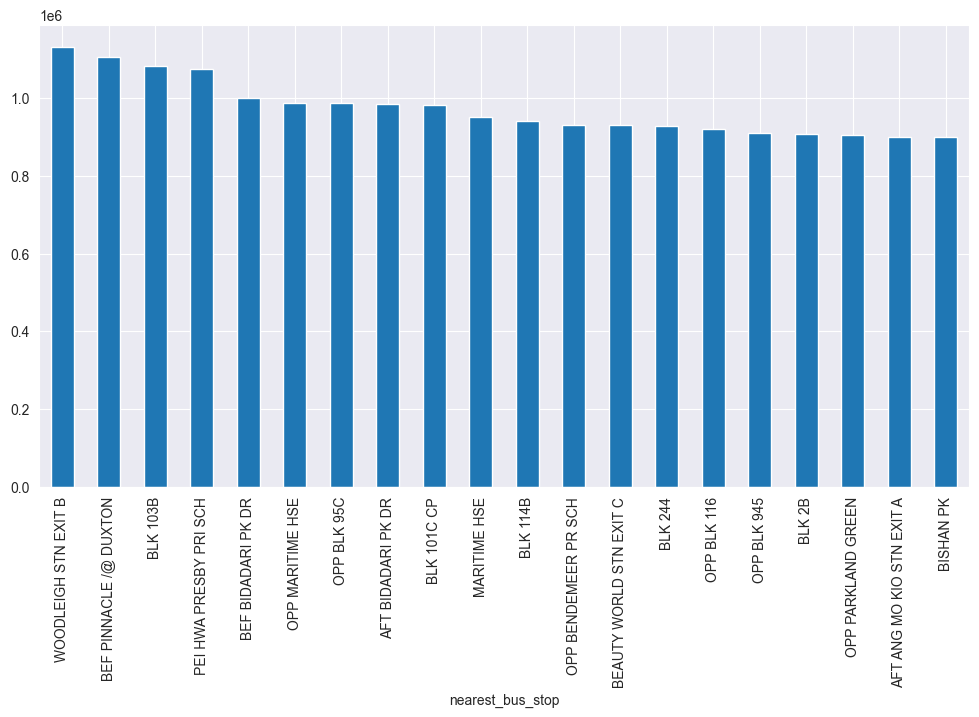

In [22]:
avg_price_by_busstop = (
    data_bus.groupby("nearest_bus_stop")["resale_price"]
      .mean()
      .sort_values(ascending=False).head(20)
)

# plot
plt.figure(figsize=(12, 6))
avg_price_by_busstop.plot(kind="bar")


<Axes: xlabel='distance_to_bus_stop', ylabel='resale_price'>

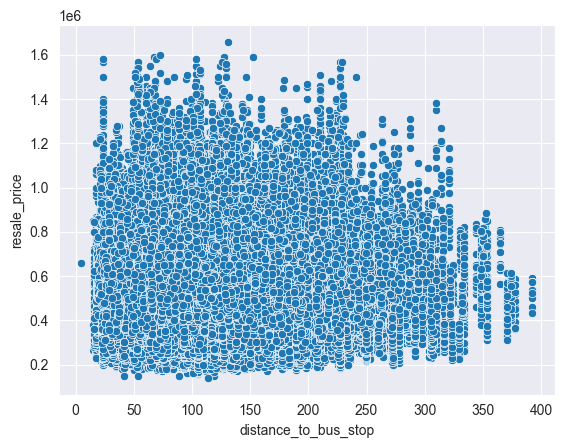

In [23]:
sns.scatterplot( x='distance_to_bus_stop', y='resale_price', data=data_bus )

In [24]:
from scipy.stats import pearsonr, spearmanr
# keep only rows where both variables exist
corr_data = data_bus[['distance_to_bus_stop', 'resale_price']].dropna()

# Pearson correlation
pearson_corr, pearson_p = pearsonr(
    corr_data['distance_to_bus_stop'],
    corr_data['resale_price']
)

# Spearman correlation
spearman_corr, spearman_p = spearmanr(
    corr_data['distance_to_bus_stop'],
    corr_data['resale_price']
)

print("Pearson correlation:", pearson_corr)
print("Pearson p-value:", pearson_p)

print("Spearman correlation:", spearman_corr)
print("Spearman p-value:", spearman_p)

Pearson correlation: 0.03258427975161191
Pearson p-value: 3.2375589316197025e-51
Spearman correlation: 0.02224206681969241
Spearman p-value: 9.173363790975892e-25


## Regression

In [26]:
numeric_features = [
    'floor_area_sqm',
    'remaining_lease_numeric',
    'distance_to_mrt',
    'distance_to_bus_stop',
    'distance_to_hawker',
    'distance_to_park',
    'distance_to_activesg'
]
categorical_features = [
    'town',
    'flat_type',
    'storey_range',
    'flat_model'
]

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

features = numeric_features + categorical_features

X=data_bus[features]
y = np.log1p(data_bus['resale_price']) #log for scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]))
])

model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

# convert predictions back from log scale
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(y_test_original, y_pred)
rmse = root_mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 80561.79786211516
RMSE: 99598.63531353712
R²: 0.7052898806849547
